### 作者：东哥起飞

### 本篇文章来源于[《100天成为风控专家》](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2ZAoFMNREbOv3DutKsoIi9Vlfky)报表篇-迁徙率报表(2)：Python代码实操

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.options.display.max_columns = 50

# 一、数据探索

In [2]:
# 数据读取
data_act=pd.read_csv("repay_actual_data_new.csv")
data_plan = pd.read_csv("repay_plan_data_new.csv")
print(data_act.shape)
print(data_plan.shape)

(3148826, 8)
(7724346, 12)


In [3]:
data_act.head(2)

,order_id,order_sub_id,phase,actual_repay_date,actual_repay_amt,actual_repay_prin,actual_repay_int,snapshot_date
0,2010100002350101000,2010100002350101001,1,20220101,3917,3884,33,20221213
1,2010100002350101000,2010100002350101002,2,20220101,3764,3764,0,20221213


In [4]:
data_plan.head(2)

,user_id,order_id,order_sub_id,phase_total,phase,expected_date,create_time,loan_amt,irr_rate,schedule_repay_prin,schedule_repay_int,snapshot_date
0,201100000360790110000,2011000035640110000,2011000035640110010,12,10,20221110,2022-01-10 17:46:31,500000.0,0.24,44545,0,20221110
1,201100000360790110000,2011000035640110000,2011000035640110011,12,11,20221210,2022-01-10 17:46:31,500000.0,0.24,45527,0,20221110


In [5]:
# 数据采用快照的形式进行抓取，提取每月月底最后数据，做数据清洗加工
# 还款计划表采用增量快照记录的方式，故采用最新的数据作为最后的主数据
data_plan12= data_plan[data_plan.snapshot_date==20221214]
data_plan12.shape

(46758, 12)

In [6]:
len(data_plan12.user_id.unique()) #截至20221214，一共有4760个客户，发生了5031笔合同支用

4760

In [7]:
len(data_plan12.order_id.unique()) # 订单数

5031

In [8]:
# 实际还款记录表，也采用快照得方式，获取最终切片数据加工,数据范围更大
data_act12= data_act[data_act.snapshot_date==20221214]

In [9]:
len(data_act12.order_id.unique()) #实际还款记录表一共有5008个合同号，最终数据与最终关联上得数据为准

5008

# 二、数据拼接

In [96]:
#---# 挑选vars
data_act_tmp = data_act12[['order_sub_id', 'actual_repay_date',
       'actual_repay_amt', 'actual_repay_prin', 'actual_repay_int']]

data_all= pd.merge(data_plan12, data_act_tmp, on ='order_sub_id', how='left')
data_all.shape

(46758, 16)

In [97]:
# 观测时点为20221231
data_all_1 = data_all[data_all.expected_date<=20221214]
data_all_1.shape

(22112, 16)

# 三、变量加工&计算

In [98]:
############################处理时间#########################################
# 定义当前观测时点
now_date = '2022-12-31'
#时间处理， dpd时间加工计算
data_all_1['actual_repay_date']=data_all_1['actual_repay_date'].astype(str).map(lambda x:x[:8])
data_all_1['expected_date']=data_all_1['expected_date'].astype(str)
#时间类型转换
data_all_1['actual_repay_date'] = pd.to_datetime(data_all_1['actual_repay_date'])
data_all_1['expected_date']=pd.to_datetime(data_all_1['expected_date'])
# 加工放款月
data_all_1['create_time'] = pd.to_datetime(data_all_1['create_time']).astype(str).map(lambda x:x[:10])
data_all_1['create_time'] = pd.to_datetime(data_all_1['create_time'])
data_all_1['loan_month'] = data_all_1['create_time'].astype(str).map(lambda x:x[:7])
# 加工mob月底观测日期
def get_month(x) : return dt.datetime(x.year,x.month,int(x.days_in_month))
data_all_1['obser_month_end'] = data_all_1.loc[data_all_1['expected_date'].isna()==False,'expected_date'].apply(get_month)
# 排序
data_all_1 = data_all_1.sort_values(['order_id','phase'],ascending=[True,True])

In [111]:
############################本金#########################################
# 计算已还本金累计和
data_all_1['actual_repay_prin_cumsum'] = data_all_1.groupby(['order_id'])['actual_repay_prin'].transform('cumsum')
# 剩余未还本金
data_all_1['balance'] = data_all_1['loan_amt']-data_all_1['actual_repay_prin_cumsum']
# 剩余未还本金下移辅助列
data_all_1['balance_sft'] = data_all_1.groupby('order_id')['balance'].transform(lambda x:x.shift(1))
############################逾期标识#########################################
# 加工出逾期标志
data_all_1['odu_flag'] = 0
data_all_1.loc[(data_all_1['actual_repay_date']>data_all_1['obser_month_end'])|(data_all_1['actual_repay_date'].isnull()),'odu_flag'] = 1
data_all_1['odu_flag_sft'] = data_all_1.groupby('order_id')['odu_flag'].transform(lambda x:x.shift(1))
data_all_1['actual_repay_date_sft'] = data_all_1.groupby('order_id')['actual_repay_date'].transform(lambda x:x.shift(1))
data_all_1['odu_first_flag'] = 0
data_all_1.loc[(data_all_1['odu_flag_sft']==0)&(data_all_1['odu_flag']==1),'odu_first_flag'] = 1
data_all_1.loc[(data_all_1['odu_flag_sft']==1)&(data_all_1['odu_flag']==1)&(data_all_1['actual_repay_date'].isnull()),'odu_first_flag'] = 2
data_all_1.loc[(data_all_1['odu_flag_sft']==1)&(data_all_1['odu_flag']==1)&(data_all_1['actual_repay_date_sft']>data_all_1['obser_month_end']),'odu_first_flag'] = 2
data_all_1.loc[(data_all_1['odu_flag_sft']==1)&(data_all_1['odu_flag']==1)&(data_all_1['actual_repay_date_sft']<=data_all_1['obser_month_end']),'odu_first_flag'] = 1
# 更新剩余本金
data_all_1.loc[data_all_1['odu_first_flag']==1,'balance'] = data_all_1['balance_sft']
data_all_1.loc[(data_all_1['odu_first_flag']==2),'balance'] = np.nan
data_all_1['balance'] = data_all_1.groupby('order_id')['balance'].transform(lambda x:x.ffill())
############################逾期天数#########################################
# 实还未超过月底观测日
data_all_1.loc[(data_all_1['actual_repay_date'].isnull()==False)&(data_all_1['actual_repay_date']<=data_all_1['obser_month_end']),'odu_days'] = 0
# 逾期-首次逾期的
data_all_1.loc[(data_all_1['odu_first_flag']==1),'odu_days'] = (data_all_1['obser_month_end']-data_all_1['expected_date']).dt.days
# 继续逾期的
data_all_1['expected_date_2'] = data_all_1['expected_date']
data_all_1.loc[(data_all_1['odu_first_flag']==2),'expected_date_2'] = np.nan
data_all_1['expected_date_2'] = data_all_1.groupby('order_id')['expected_date_2'].transform(lambda x:x.ffill())
data_all_1.loc[(data_all_1['odu_first_flag']==2),'odu_days'] = (data_all_1['obser_month_end']-data_all_1['expected_date_2']).dt.days
############################M逾期期数#########################################
# data_all_1['odu_status'] = ''
data_all_1.loc[data_all_1['odu_days']<1, 'odu_status'] = 'M0'
data_all_1.loc[(1<=data_all_1['odu_days'])&(data_all_1['odu_days']<=30), 'odu_status'] = 'M1'
data_all_1.loc[(30<data_all_1['odu_days'])&(data_all_1['odu_days']<=60), 'odu_status'] = 'M2'
data_all_1.loc[(60<data_all_1['odu_days'])&(data_all_1['odu_days']<=90), 'odu_status'] = 'M3'
data_all_1.loc[(90<data_all_1['odu_days'])&(data_all_1['odu_days']<=120), 'odu_status'] = 'M4'
data_all_1.loc[(120<data_all_1['odu_days'])&(data_all_1['odu_days']<=150), 'odu_status'] = 'M5'
data_all_1.loc[(150<data_all_1['odu_days'])&(data_all_1['odu_days']<=180), 'odu_status'] = 'M6'
data_all_1.loc[(180<data_all_1['odu_days'])&(data_all_1['odu_days']<=210), 'odu_status'] = 'M7'
data_all_1.loc[(210<data_all_1['odu_days'])&(data_all_1['odu_days']<=240), 'odu_status'] = 'M8'
data_all_1.loc[(240<data_all_1['odu_days']), 'odu_status'] = 'M9+'
data_all_1['obser_month'] =  data_all_1['obser_month_end'].astype(str).map(lambda x:x[:7])
############################逾期金额#########################################
# cond = data_all_1['odu_days']>30
# data_all_1['overdue_amt'] = data_all_1['balance'].where(cond, other=0)
############################MOB计算#########################################
# 加工mob账龄数
# data_all_1['mob'] = (data_all_1['obser_month_end'] - data_all_1['create_time']).dt.days/30
# data_all_1['mob'] = data_all_1['mob'].round(0)

In [112]:
# 查看逾期期数分布
data_all_1['odu_status'].value_counts()

odu_status
M0     21441
M1       287
M2       131
M3        77
M4        53
M5        35
M6        26
M7        12
M8         7
M9+        5
Name: count, dtype: int64

In [113]:
# data_all_1[(data_all_1['loan_month']=='2022-01')&(data_all_1['odu_status']=='M2')]
# data_all_1[data_all_1['order_id']==2013100022940131000]
# data_all_1[(data_all_1['obser_month']=='2022-11')&(data_all_1['odu_status']=='M7+')]

In [120]:
# 生成迁徙率表格
migr_1 = pd.pivot_table(data_all_1, index='odu_status', columns='obser_month', values='balance', aggfunc='sum').sort_index()
migr_df = migr_1.shift(-1,axis=1).shift(-1,axis=0)/migr_1
migr_df = migr_df.iloc[:-1,1:11]
migr_df.index = ['MO->M1','M1->M2','M2->M3','M3->M4','M4->M5','M5->M6','M6->M7','M7->M8','M8->M9+']
migr_df.iloc[:-1,:-1] # 快照时间为12月14日，因此12月14至12月31数据不全，最后一列数据不准确去掉不作为参考

obser_month,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10
MO->M1,NaN,0.012418,0.006446,0.015737,0.011950,0.006880,0.014477,0.018159,0.019502
M1->M2,NaN,NaN,0.934607,0.616183,0.748691,0.547913,0.916843,0.620522,0.611262
M2->M3,NaN,NaN,NaN,0.949100,0.735511,0.914555,0.791967,0.587282,0.761384
M3->M4,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.095075,1.000000
M4->M5,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,0.857247,0.773313
M5->M6,NaN,NaN,NaN,NaN,NaN,NaN,0.832418,1.000000,0.895923
M6->M7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000
M7->M8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000


## 二、可视化

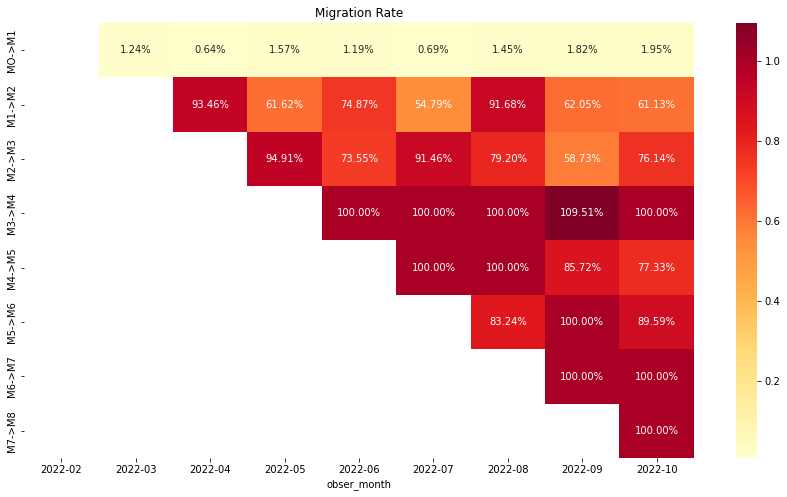

In [132]:
# 迁徙率
import seaborn as sns
plt.figure(figsize=(15, 8))
plt.title('Migration Rate')
sns.heatmap(data=migr_df.iloc[:-1,:-1],annot = True,fmt = '.2%',cmap='YlOrRd')
plt.show()

In [251]:
# migr_df.iloc[:-1,:-1].to_excel('migration.xlsx',index=False)

# 番外

如果对pandas不熟悉想要进阶的朋友可以了解下东哥的这个原创笔记，已经完全体，后续随着版本迭代会持续更新。

[《pandas进阶宝典》](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2YD5u0x8FzrAIyM8soEuxnTkP9r)永久访问权限，500页图文笔记，近30万字，配套完整代码支持下载。

5大核心图文，具体包括：
- 《pandas快速入门》
- 《pandas进阶宝典》
- 《pandas实战项目》
- 《pandas进阶题库》
- 《Numpy速查手册》
- 《正则表达式手册》

感兴趣可以扫码了解，或者加我微信可以有折扣，加V：`Petery_1966`

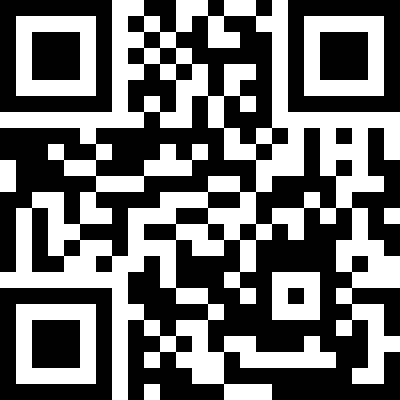